# Job Information

When applying the techniques in the previous notebooks, we will want to understand the scale and scope of our work better.

Some things we might want to know on a job include:
- How many acres is the total mapped area?
    - Can we see the area divided into 1-acre plots?
- How many total plants are detected?
    - How much product is needed to treat all of these plants?
- How long is the journey to treat all plants?
    - How many drone batteries might that take?

This notebook will provide code to help answer some of these questions.

In [1]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

from plant_search.load_image import load_image, plot_image


# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'
file_path = '../input/IGNORE_Brewster-ortho.tif'


In [ ]:
ds = 8 # downscale ratio

image = load_image(file_path)
if image is not None:
    image = image[::ds, ::ds]
    plot_image(image, "Original Image")

print(f"Scaled image dimensions: {image.shape}")

In [2]:
from pyproj import Geod
from shapely.geometry import box
import rasterio

def calculate_land_area(bounds, crs):
    """
    Calculate the land area represented by the GeoTIFF.
    - For geographic CRS: Use geodesic area.
    - For projected CRS: Calculate directly.
    """
    if crs.is_geographic:
        # Use geodesic method for geographic CRS
        geod = Geod(ellps="WGS84")
        geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
        area_m2, _ = geod.geometry_area_perimeter(geom)
    else:
        # Calculate directly for projected CRS
        width = bounds.right - bounds.left  # in CRS units (e.g., meters)
        height = bounds.top - bounds.bottom
        area_m2 = width * height
    
    area_acres = area_m2 / 4046.86  # Convert square meters to acres
    return area_m2, area_acres


geotiff_path = file_path

with rasterio.open(geotiff_path) as src:
    bounds = src.bounds
    crs = src.crs
    area_m2, area_acres = calculate_land_area(bounds, crs)

print(f"Land Area: {area_m2:.2f} m² ({area_acres:.2f} acres)")


Land Area: 291433.93 m² (72.01 acres)


## Polygon Partitioning & Subdivision


### Vocabulary and Problem Context

1. **Region or Input Polygon:**
   - This is the irregular boundary (e.g., your GeoTIFF's extent or another polygon) that you want to partition.
   - Defined as a closed polygonal shape, often represented as a **shapely.geometry.Polygon** or in GeoJSON format.

2. **Partitioning:**
   - The process of dividing the polygon into smaller polygons or subregions.
   - The goal here is to create as many **subregions** as possible, each with a target area (e.g., 1 acre).

3. **Target Area:**
   - The desired area of each subregion. For example, 1 acre (~4046.86 m²).
   - Any remainder will form a smaller subregion.

4. **Compactness:**
   - Refers to the shape of the subregions, favoring more regular (e.g., circular or square-like) shapes.
   - This avoids "spindly" or elongated polygons.

5. **Spatial Packing:**
   - A mathematical problem related to fitting shapes (e.g., circles, hexagons, or squares) into a bounded area with minimal gaps or overlaps.
   - Common approaches include:
     - **Hexagonal Tiling:** Provides the most efficient packing in a 2D plane for compact regions.
     - **Square Grid Tiling:** Easier to compute but less efficient.

6. **Polygon Clipping:**
   - Cutting out portions of shapes when they overlap or exceed the bounds of the region polygon.
   - Libraries like `shapely` or `clipper` are often used for this step.

7. **Centroidal Voronoi Tessellation (CVT):**
   - A more advanced method to partition a region into compact areas of nearly equal size while maintaining adjacency constraints.
   - This method adapts the partition to the specific shape of the input polygon.

8. **Optimization Constraints:**
   - Maximizing the number of subregions while meeting area constraints.
   - Ensuring geometric and topological validity (e.g., no overlaps, no gaps).

---

### Known Solutions and Techniques

1. **Regular Tiling (Hexagonal or Square):**
   - Simpler and faster to compute.
   - Best for polygons that approximate a rectangular or compact shape.
   - Example: Use a grid of hexagons or squares to cover the region, then clip the grid to the polygon.

2. **Voronoi-Based Partitioning:**
   - A dynamic method that adjusts the location of subregions iteratively.
   - Ensures nearly equal areas while conforming to the shape of the polygon.
   - Tools: `scipy.spatial.Voronoi` or `geovoronoi`.

3. **Centroidal Voronoi Tessellation (CVT):**
   - A refinement of Voronoi tessellation that iteratively adjusts cell centroids to equalize areas.
   - Computationally intensive but produces high-quality partitions.

4. **Geometric Optimization:**
   - Use algorithms like **linear programming** or **simulated annealing** to find optimal partition configurations.
   - Useful for irregular polygons where packing circles or squares is challenging.

5. **Shape Packing with Overlap Clipping:**
   - Generate a grid of candidate shapes (e.g., circles) and clip them to the polygon.
   - Sort and validate based on area constraints.

Generated polygons:                                              geometry
0   POLYGON ((-103.60521 30.24709, -103.60522 30.2...
1   POLYGON ((-103.60457 30.24709, -103.60457 30.2...
2   POLYGON ((-103.60392 30.24709, -103.60393 30.2...
3   POLYGON ((-103.60328 30.24709, -103.60328 30.2...
4   POLYGON ((-103.60263 30.24709, -103.60264 30.2...
..                                                ...
79  POLYGON ((-103.6007 30.25044, -103.6007 30.250...
80  POLYGON ((-103.60006 30.25044, -103.60006 30.2...
81  POLYGON ((-103.59941 30.25044, -103.59941 30.2...
82  POLYGON ((-103.59877 30.25044, -103.59877 30.2...
83  POLYGON ((-103.59812 30.25044, -103.59812 30.2...

[84 rows x 1 columns]


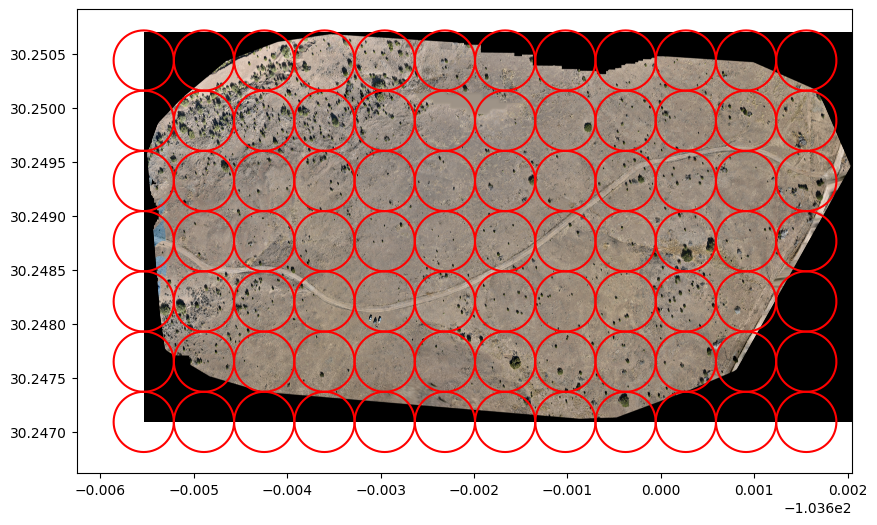

In [10]:
from pyproj import CRS, Transformer
from shapely.geometry import Point, box
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import rasterio.plot

# Constants
ACRE_TO_SQ_METERS = 4046.86  # 1 acre = 4046.86 square meters

# Step 1: Load the GeoTIFF
def load_geotiff(file_path):
    with rasterio.open(file_path) as src:
        bounds = src.bounds
        crs = src.crs
    return bounds, crs

def transform_bounds(bounds, src_crs, target_crs):
    """
    Reproject the bounds from one CRS to another.
    
    Parameters:
        bounds (tuple): Bounding box in the format (minx, miny, maxx, maxy).
        src_crs (CRS): Source CRS.
        target_crs (CRS): Target CRS.

    Returns:
        tuple: Reprojected bounds in the target CRS.
    """
    transformer = Transformer.from_crs(src_crs, target_crs, always_xy=True)
    minx, miny = transformer.transform(bounds[0], bounds[1])
    maxx, maxy = transformer.transform(bounds[2], bounds[3])
    return minx, miny, maxx, maxy

def generate_circular_sections(bounds, original_crs, target_area_sqm):
    """
    Generate circular sections in a projected CRS, then reproject back to the original CRS.
    """
    # Reproject bounds to a projected CRS for accurate calculations
    projected_crs = CRS.from_epsg(3857)  # Web Mercator; can choose UTM if known
    projected_bounds = transform_bounds(bounds, original_crs, projected_crs)
    
    # Calculate radius and grid spacing in the projected CRS
    radius = np.sqrt(target_area_sqm / np.pi)
    grid_spacing = 2 * radius

    # Create circular polygons in the projected CRS
    minx, miny, maxx, maxy = projected_bounds
    polygons = []
    y = miny
    while y < maxy:
        x = minx
        while x < maxx:
            center = Point(x, y)
            polygon = center.buffer(radius)  # Create circular polygon
            polygons.append(polygon)
            x += grid_spacing
        y += grid_spacing

    # Convert polygons to GeoDataFrame and reproject back to the original CRS
    projected_gdf = gpd.GeoDataFrame({"geometry": polygons}, crs=projected_crs)
    original_gdf = projected_gdf.to_crs(original_crs)
    return original_gdf

# Visualization function remains unchanged
def visualize_geotiff_with_polygons(geotiff_path, polygons_gdf):
    with rasterio.open(geotiff_path) as src:
        fig, ax = plt.subplots(figsize=(10, 10))
        rasterio.plot.show(src, ax=ax)  # Display GeoTIFF
        polygons_gdf.boundary.plot(ax=ax, edgecolor='red')  # Overlay polygons
        plt.show()


# Example Usage
geotiff_path = file_path
bounds, crs = load_geotiff(geotiff_path)
target_area_sqm = ACRE_TO_SQ_METERS  # 1 acre in square meters
polygons_gdf = generate_circular_sections(bounds, crs, target_area_sqm)

print(f"Generated polygons: {polygons_gdf}")

visualize_geotiff_with_polygons(geotiff_path, polygons_gdf)


### Land Area Measurement and Visualization

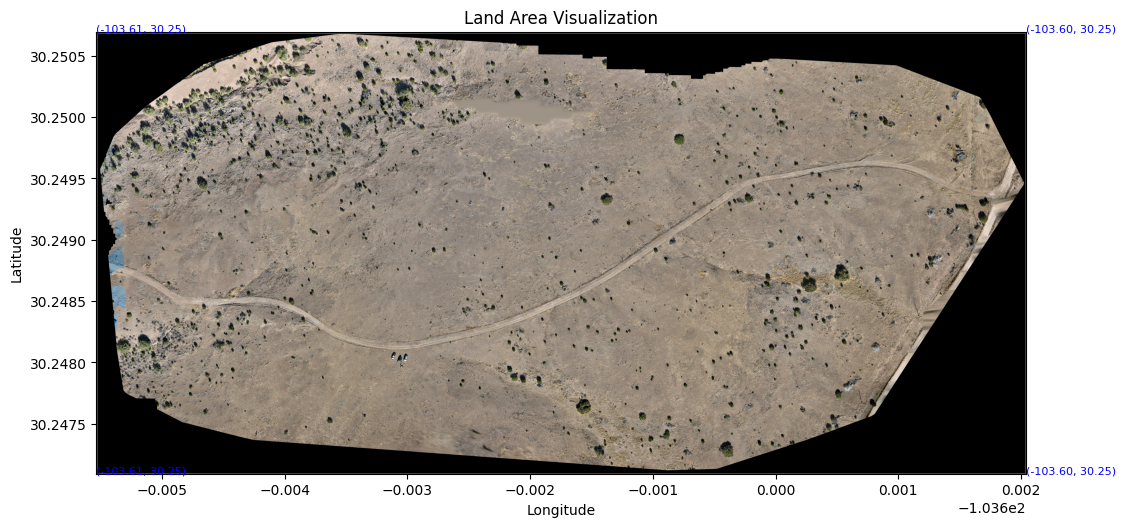

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from rasterio.plot import show
import rasterio

def visualize_land_area(raster_path):
    """
    Visualize the GeoTIFF with its bounding box and coordinates.
    """
    with rasterio.open(raster_path) as src:
        bounds = src.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
        
        # Plot the raster
        fig, ax = plt.subplots(figsize=(12, 8))
        show(src, ax=ax, cmap='gray')
        
        # Add bounding box rectangle
        rect = Rectangle(
            (bounds.left, bounds.bottom),  # Lower-left corner
            bounds.right - bounds.left,   # Width
            bounds.top - bounds.bottom,   # Height
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Annotate corners
        ax.text(bounds.left, bounds.bottom, f"({bounds.left:.2f}, {bounds.bottom:.2f})", color="blue", fontsize=8)
        ax.text(bounds.right, bounds.bottom, f"({bounds.right:.2f}, {bounds.bottom:.2f})", color="blue", fontsize=8)
        ax.text(bounds.left, bounds.top, f"({bounds.left:.2f}, {bounds.top:.2f})", color="blue", fontsize=8)
        ax.text(bounds.right, bounds.top, f"({bounds.right:.2f}, {bounds.top:.2f})", color="blue", fontsize=8)
        
        # Add labels and title
        ax.set_title("Land Area Visualization")
        ax.set_xlabel("Longitude" if src.crs.is_geographic else "X (Projected)")
        ax.set_ylabel("Latitude" if src.crs.is_geographic else "Y (Projected)")
        
        plt.show()


visualize_land_area(file_path)


In [3]:
import rasterio
from pyproj import Geod
import numpy as np
import geopandas as gpd
from shapely.geometry import box

def calculate_acreage_without_reproject(bounds, width, height, crs):
    geod = Geod(ellps="WGS84")  # Use the WGS84 ellipsoid for distance calculations
    
    # Calculate pixel size in meters
    x_pixels = width
    y_pixels = height
    pixel_width_deg = (bounds.right - bounds.left) / x_pixels
    pixel_height_deg = (bounds.top - bounds.bottom) / y_pixels
    
    # Approximate area of the full raster using geodesic calculation
    total_area_m2, _ = geod.geometry_area_perimeter(box(bounds.left, bounds.bottom, bounds.right, bounds.top))
    total_area_acres = total_area_m2 / 4046.86
    return total_area_acres, pixel_width_deg, pixel_height_deg

def generate_one_acre_grids(bounds, crs, pixel_width_deg, pixel_height_deg):
    # Approximate degree size for 1 acre in the current CRS
    one_acre_m2 = 4046.86
    grid_boxes = []
    
    # Step size approximation for 1 acre in degrees (latitude and longitude)
    step_lat = pixel_height_deg * (one_acre_m2 ** 0.5 / pixel_height_deg)
    step_lon = pixel_width_deg * (one_acre_m2 ** 0.5 / pixel_width_deg)
    
    # Generate grid
    y_coords = np.arange(bounds.bottom, bounds.top, step_lat)
    x_coords = np.arange(bounds.left, bounds.right, step_lon)
    
    for x in x_coords:
        for y in y_coords:
            grid_boxes.append(box(x, y, x + step_lon, y + step_lat))
    
    grid_gdf = gpd.GeoDataFrame({"geometry": grid_boxes}, crs=crs)
    return grid_gdf

# Example usage
geotiff_path = file_path

with rasterio.open(geotiff_path) as src:
    bounds = src.bounds
    width = src.width
    height = src.height
    crs = src.crs

area_acres, pixel_width_deg, pixel_height_deg = calculate_acreage_without_reproject(bounds, width, height, crs)
grid_gdf = generate_one_acre_grids(bounds, crs, pixel_width_deg, pixel_height_deg)

print(f"Total Area: {area_acres:.2f} acres")


Total Area: 72.01 acres


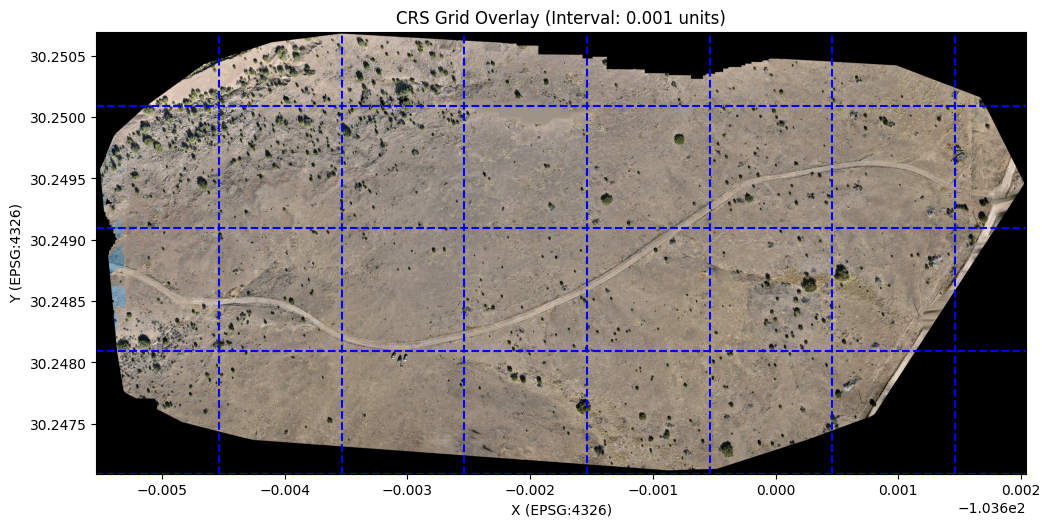

In [2]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

def visualize_crs_grid(raster_path, grid_interval):
    """
    Visualize the raster with a grid overlay in its CRS.
    
    Parameters:
    - raster_path: Path to the GeoTIFF file.
    - grid_interval: Spacing of grid lines in CRS units (e.g., degrees or meters).
    """
    with rasterio.open(raster_path) as src:
        bounds = src.bounds
        crs = src.crs
        
        # Create the grid lines
        x_coords = np.arange(bounds.left, bounds.right, grid_interval)
        y_coords = np.arange(bounds.bottom, bounds.top, grid_interval)
        
        # Plot the raster
        fig, ax = plt.subplots(figsize=(12, 8))
        show(src, ax=ax, cmap='gray')
        
        # Plot vertical grid lines
        for x in x_coords:
            ax.plot([x, x], [bounds.bottom, bounds.top], color="blue", linestyle="--", linewidth=1.5)
        
        # Plot horizontal grid lines
        for y in y_coords:
            ax.plot([bounds.left, bounds.right], [y, y], color="blue", linestyle="--", linewidth=1.5)
        
        # Add labels and title
        ax.set_title(f"CRS Grid Overlay (Interval: {grid_interval} units)")
        ax.set_xlabel(f"X ({crs})")
        ax.set_ylabel(f"Y ({crs})")
        
        plt.show()

# Filepath to your GeoTIFF
raster_path = file_path

# Set grid interval (e.g., 1 degree or 1000 meters depending on CRS)
grid_interval = 0.001 if 'GEOGCS' in rasterio.open(raster_path).crs.to_wkt() else 100

# Visualize CRS grid
visualize_crs_grid(raster_path, grid_interval)


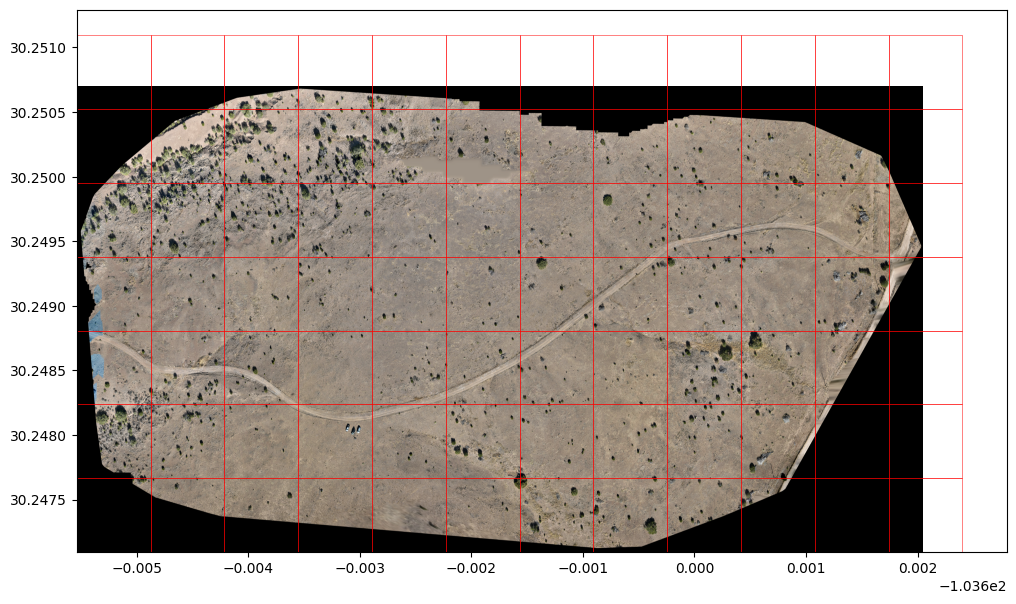

In [2]:
# from shapely.geometry import box
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import rasterio
# from rasterio.plot import show
# import numpy as np

# def generate_one_acre_grids_corrected(bounds, crs):
#     # Convert 1 acre to approximate degree dimensions
#     one_acre_m2 = 4046.86
#     grid_boxes = []

#     # Estimate degree size for 1 acre at the equator (approximation)
#     # Adjust step sizes based on the approximate size of a degree in meters
#     step_lat = 1 / (111320 / np.sqrt(one_acre_m2))  # Approx lat degrees for 1-acre
#     step_lon = 1 / (111320 * np.cos(np.radians((bounds.top + bounds.bottom) / 2)) / np.sqrt(one_acre_m2))  # Approx lon degrees

#     # Generate grid covering the raster's bounds
#     y_coords = np.arange(bounds.bottom, bounds.top, step_lat)
#     x_coords = np.arange(bounds.left, bounds.right, step_lon)

#     for x in x_coords:
#         for y in y_coords:
#             # Create a grid box
#             grid_boxes.append(box(x, y, x + step_lon, y + step_lat))

#     # Create GeoDataFrame
#     grid_gdf = gpd.GeoDataFrame({"geometry": grid_boxes}, crs=crs)

#     # Clip grid to raster bounds
#     raster_bounds_geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
#     grid_gdf = grid_gdf[grid_gdf.geometry.intersects(raster_bounds_geom)]

#     return grid_gdf

# def visualize_1_acre_grids_corrected(raster_path, grid_gdf):
#     # Open the raster file
#     with rasterio.open(raster_path) as src:
#         # Plot the raster
#         fig, ax = plt.subplots(figsize=(12, 8))
#         raster_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
#         show(src, extent=raster_extent, ax=ax, cmap='gray')

#         # Plot the 1-acre grid
#         grid_gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=0.5, alpha=0.7)

#         # Add labels and title

# # Filepath to your GeoTIFF
# geotiff_path = file_path

# with rasterio.open(geotiff_path) as src:
#     bounds = src.bounds
#     width = src.width
#     height = src.height
#     crs = src.crs

# grid_gdf = generate_one_acre_grids_corrected(bounds, crs)
# visualize_1_acre_grids_corrected(geotiff_path, grid_gdf)


In [ ]:
# import rasterio
# from rasterio.plot import show
# from rasterio.warp import calculate_default_transform, reproject, Resampling
# from shapely.geometry import box
# import geopandas as gpd
# import matplotlib.pyplot as plt

# def reproject_to_meters(src_path, dst_path):
#     """Reproject the GeoTIFF to a CRS with meters (e.g., UTM)."""
#     with rasterio.open(src_path) as src:
#         # Calculate transformation to a projected CRS (UTM based on image center)
#         dst_crs = rasterio.crs.CRS.from_epsg(32633)  # Replace with desired EPSG (e.g., UTM zone)
#         transform, width, height = calculate_default_transform(
#             src.crs, dst_crs, src.width, src.height, *src.bounds
#         )
        
#         kwargs = src.meta.copy()
#         kwargs.update({
#             'crs': dst_crs,
#             'transform': transform,
#             'width': width,
#             'height': height
#         })
        
#         with rasterio.open(dst_path, 'w', **kwargs) as dst:
#             for i in range(1, src.count + 1):
#                 reproject(
#                     source=rasterio.band(src, i),
#                     destination=rasterio.band(dst, i),
#                     src_transform=src.transform,
#                     src_crs=src.crs,
#                     dst_transform=transform,
#                     dst_crs=dst_crs,
#                     resampling=Resampling.nearest
#                 )
#     return dst_path

# def reproject_to_meters_optimized(src_path, dst_path, target_crs=None):
#     """Reproject the GeoTIFF to a CRS with meters, matching the original resolution and applying compression."""
#     with rasterio.open(src_path) as src:
#         # Set target CRS (default: UTM based on the image center)
#         if target_crs is None:
#             centroid = ((src.bounds.left + src.bounds.right) / 2, 
#                         (src.bounds.top + src.bounds.bottom) / 2)
#             utm_zone = int((centroid[0] + 180) // 6) + 1
#             is_northern = centroid[1] >= 0
#             target_crs = f"EPSG:{32600 + utm_zone if is_northern else 32700 + utm_zone}"
        
#         transform, width, height = calculate_default_transform(
#             src.crs, target_crs, src.width, src.height, *src.bounds
#         )
        
#         # Match resolution to the original
#         dst_resolution = (src.res[0], src.res[1])
#         width = int((src.bounds.right - src.bounds.left) / dst_resolution[0])
#         height = int((src.bounds.top - src.bounds.bottom) / dst_resolution[1])
        
#         kwargs = src.meta.copy()
#         kwargs.update({
#             'crs': target_crs,
#             'transform': transform,
#             'width': width,
#             'height': height,
#             'compress': 'lzw'  # Add compression
#         })
        
#         with rasterio.open(dst_path, 'w', **kwargs) as dst:
#             for i in range(1, src.count + 1):
#                 reproject(
#                     source=rasterio.band(src, i),
#                     destination=rasterio.band(dst, i),
#                     src_transform=src.transform,
#                     src_crs=src.crs,
#                     dst_transform=transform,
#                     dst_crs=target_crs,
#                     resampling=Resampling.nearest  # Use nearest neighbor for speed
#                 )
#     return dst_path


# def load_geotiff(filepath):
#     # Load the GeoTIFF file
#     with rasterio.open(filepath) as src:
#         bounds = src.bounds
#         resolution = src.res
#         crs = src.crs
#         data = src.read(1)  # Load the first band (can be adjusted based on the file)
        
#     return bounds, resolution, crs, data

# def calculate_acreage(bounds):
#     # Calculate the acreage of the image
#     width = bounds.right - bounds.left  # in meters
#     height = bounds.top - bounds.bottom  # in meters
#     area_m2 = width * height  # Area in square meters
#     area_acres = area_m2 / 4046.86  # Convert square meters to acres
#     return area_acres

# def draw_acre_regions(bounds, crs):
#     # Create a grid of 1-acre boxes
#     one_acre_m = 4046.86  # 1 acre in square meters
#     width = bounds.right - bounds.left
#     height = bounds.top - bounds.bottom
    
#     grid_boxes = []
#     x_step = y_step = one_acre_m ** 0.5  # Convert 1 acre to square side length in meters
    
#     x_min, x_max = bounds.left, bounds.right
#     y_min, y_max = bounds.bottom, bounds.top

#     # Generate the grid
#     x_coords = list(range(int(x_min), int(x_max), int(x_step)))
#     y_coords = list(range(int(y_min), int(y_max), int(y_step)))
    
#     for x in x_coords:
#         for y in y_coords:
#             # Create a box for each 1-acre region
#             grid_boxes.append(box(x, y, x + x_step, y + y_step))
    
#     # Create a GeoDataFrame for the grid
#     grid_gdf = gpd.GeoDataFrame({"geometry": grid_boxes}, crs=crs)
#     return grid_gdf

# def plot_with_regions(data, grid_gdf, bounds, crs):
#     # Plot the raster data and overlay the grid
#     fig, ax = plt.subplots(figsize=(12, 8))
    
#     # Plot the raster
#     raster_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
#     ax.imshow(data, extent=raster_extent, cmap="gray", origin="upper")
    
#     # Plot the grid
#     grid_gdf.boundary.plot(ax=ax, color="red", linewidth=0.5, alpha=0.7)
    
#     # Set equal aspect manually
#     ax.set_aspect("equal")
    
#     plt.title("1-Acre Regions on the GeoTIFF")
#     plt.show()


# # Filepath to your GeoTIFF
# reprojected_path = "../outputs/10_job_info/reprojected.tif"

# # Reproject the GeoTIFF to meters-based CRS
# # reproject_to_meters(file_path, reprojected_path)
# reproject_to_meters_optimized(file_path, reprojected_path)

# # Process the GeoTIFF
# bounds, resolution, crs, data = load_geotiff(reprojected_path)
# area_acres = calculate_acreage(bounds)

# print(f"Total Area: {area_acres:.2f} acres")

# # Plot the GeoTIFF with 1-acre regions
# # grid_gdf = draw_acre_regions(bounds, crs)
# # plot_with_regions(data, grid_gdf, bounds, crs)

# # 370.08 acres?
# # 66.26 acres second run
